In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler

device = torch.device("cpu")

In [2]:

if __name__ == '__main__':
    
    bench_repeat_loss_list = []
    regression_loss_total_list = []
    model_loss_total_list = []
    regression_loss_predindex_list = []
    model_loss_predindex_list = []
    bench1_loss_list = []
    bench2_loss_list = []
    bench2loss_predindex_list = []
    bench_repeat_loss_predindex_list = []
    benchloss_predindex_list = []
    models = []
    


    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 12             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 8
    nrepp = 10
    seeds = [42]
    
    
    for iteration in range(len(seeds)):
        
        # Set the random seed for reproducibility
        seed = seeds[iteration]
        torch.manual_seed(seed)

        if data_str == "simulation":
            n = 500 
            p = 10
            maxlen = 10
            # Create Dataset and DataLoader
            train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
            eval_dataset = SimulatedDataset(1000, p, maxlen=maxlen, device = device).data
            predindex = 2
            
        else:
            # load real data
            data, maxlen = load_real_data(data_str)
            
            n = int(0.8*len(data))
            p = data[0].shape[1]
            print("Sample size: ", len(data))
            
            train_dataset = data[:n]
            eval_dataset = data[n:]
            predindex = 9

        

        mask_pairwise = create_custom_mask_pair(maxlen, device)
        distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
        pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)

    
        dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
        
        eval_dataloader = DataLoader(eval_dataset, batch_size=1000, shuffle=False, collate_fn=collate_function, num_workers=0)
       
    
        models.append(MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device))




        print("distance to end par:", models[iteration].multiheadattn.distance_to_end_weight.item(), "\n")
        print("distance between pair par:", models[iteration].multiheadattn.distance_between_two_positions_weight.item(), "\n")


        # models[iteration].apply(init_weights_recursive)
        models[iteration].to(device)

        # model = torch.compile(model)
        # Start the timer
        start_time = time.time()

        # Define optimizer
        # optimizer = optim.Adam(models[iteration].parameters(), lr= learning_rate, weight_decay=lambda_l2)
        optimizer = optim.Adam(models[iteration].parameters(), lr= learning_rate)
        
        print("Number of Parameters", transformerFunctions.count_parameters(models[iteration]))
        
        run_path = transformerFunctions.train_mini_transformer(models[iteration], dataloader, eval_dataloader, optimizer, lambda_l2, EPOCHS, device)


        # End the timer
        end_time = time.time()

        # Calculate and print the execution time
        execution_time = end_time - start_time 
        print(f"Execution time: {execution_time:.6f} seconds")
        
        # Evaluate the model
        
        eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=False, collate_fn=collate_function, num_workers=0)
       

    

distance to end par: -0.07934059947729111 

distance between pair par: -0.022634029388427734 

Number of Parameters 452
EPOCH 1:
avg_loss:     17.63918 penalty    : 0.01688
avg_loss_val: 10.48912 penalty_val: 0.01687
EPOCH 11:
avg_loss:     8.09603 penalty    : 0.02292
avg_loss_val: 8.54559 penalty_val: 0.02293
EPOCH 21:
avg_loss:     7.95139 penalty    : 0.03452
avg_loss_val: 8.35621 penalty_val: 0.03452
EPOCH 31:
avg_loss:     7.88531 penalty    : 0.04413
avg_loss_val: 8.30785 penalty_val: 0.04413
EPOCH 41:
avg_loss:     7.86070 penalty    : 0.04907
avg_loss_val: 8.25389 penalty_val: 0.04907
EPOCH 51:
avg_loss:     7.83082 penalty    : 0.05314
avg_loss_val: 8.21814 penalty_val: 0.05313
EPOCH 61:
avg_loss:     7.80984 penalty    : 0.05668
avg_loss_val: 8.23027 penalty_val: 0.05668
EPOCH 71:
avg_loss:     7.79882 penalty    : 0.05963
avg_loss_val: 8.22494 penalty_val: 0.05963
EPOCH 81:
avg_loss:     7.78891 penalty    : 0.06179
avg_loss_val: 8.20969 penalty_val: 0.06178
EPOCH 91:
avg_l

In [3]:
eval_dataset[5]

tensor([[1., 1., 0., 1., 0., 1., 1., 0., 1., 1.],
        [1., 1., 0., 1., 0., 1., 1., 0., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 0., 1.]])

In [4]:
eval_dataset[1]

tensor([[1., 0., 0., 1., 0., 1., 1., 1., 1., 1.],
        [1., 1., 0., 1., 0., 1., 1., 1., 1., 0.],
        [0., 1., 1., 1., 1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 0., 1., 0., 1., 1., 1.]])

In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Choose which trained model to inspect (0–9)
model_idx = -1  # -1 = last model trained
model = models[model_idx]
model.eval()


viz_dataset = SimulatedDataset(100, p, maxlen=10, device=device).data

# Build a DataLoader over the visualization dataset with batch_size=1
cumulant_loader = DataLoader(viz_dataset, batch_size=1, shuffle=False, collate_fn=collate_function, num_workers=0)


In [12]:
import numpy as np

In [ ]:
# Extract cumulants for multiple sequences (at least 10)
num_sequences = min(20, len(viz_dataset))
all_cumulants = []
pred_var = []
first_var = []
second_var = []

# Iterate through the loader properly
for i, (x_batch, mask_batch) in enumerate(cumulant_loader):
    if i >= num_sequences:
        break
    x_batch = x_batch.to(device)
    mask_batch = mask_batch.to(device)
    
    with torch.no_grad():
        # MultiHeadAttention returns the cumulant outputs before the final prediction layer
        cumulants = model.multiheadattn((x_batch, mask_batch))  # shape: (batch_size, seq_len, ncum)
        # Remove batch dimension since batch_size=1
        cumulants_np = cumulants.detach().cpu().numpy().squeeze(0)  # shape: (seq_len, ncum)
        all_cumulants.append(cumulants_np)
        
        pred_var.append(x_batch[:, :, predindex][0].tolist())
        first_var.append(x_batch[:, :, 0][0].tolist())
        second_var.append(x_batch[:, :, 1][0].tolist())
        


number of timesteps 4
timesteps [2 3 4 5]
timesteps2 [1 2 3 4 5]
pred_var 5


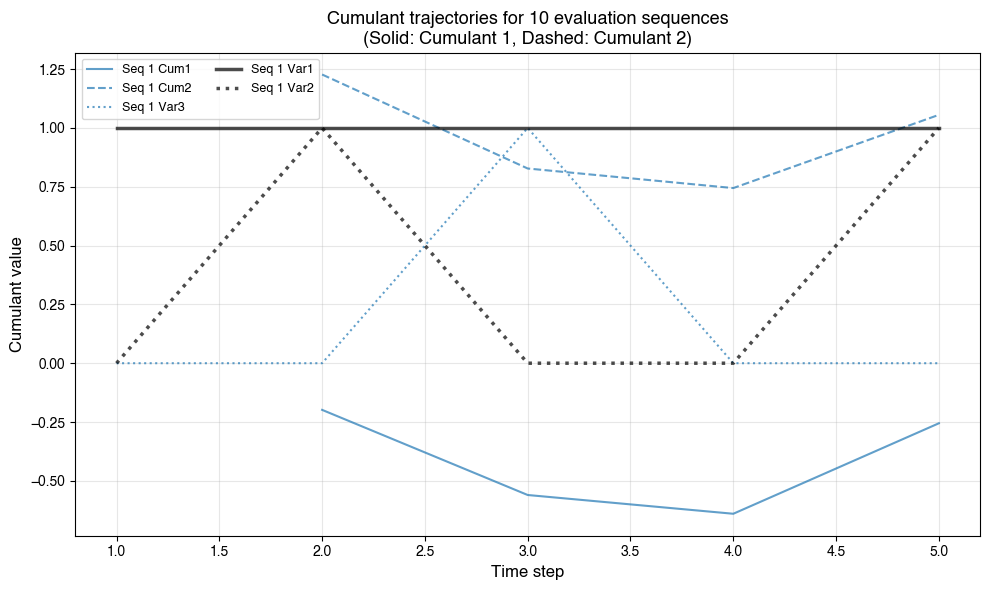

number of timesteps 9
timesteps [ 2  3  4  5  6  7  8  9 10]
timesteps2 [ 1  2  3  4  5  6  7  8  9 10]
pred_var 10


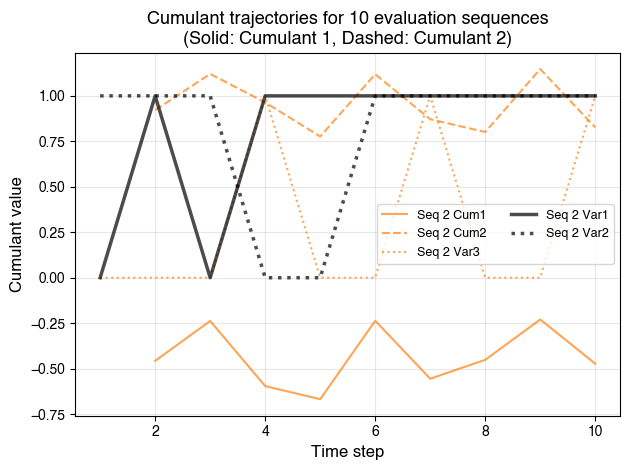

number of timesteps 9
timesteps [ 2  3  4  5  6  7  8  9 10]
timesteps2 [ 1  2  3  4  5  6  7  8  9 10]
pred_var 10


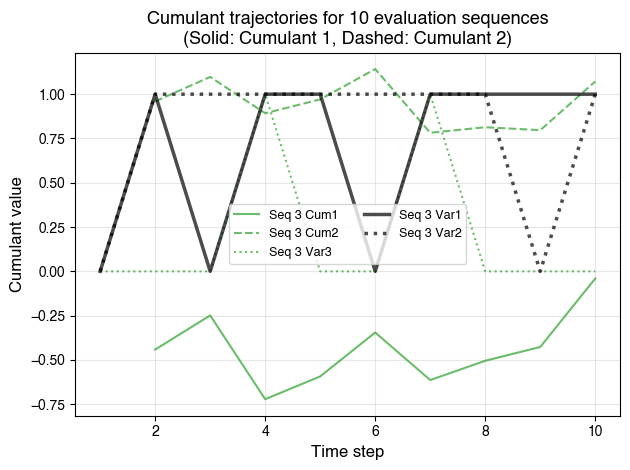

number of timesteps 3
timesteps [2 3 4]
timesteps2 [1 2 3 4]
pred_var 4


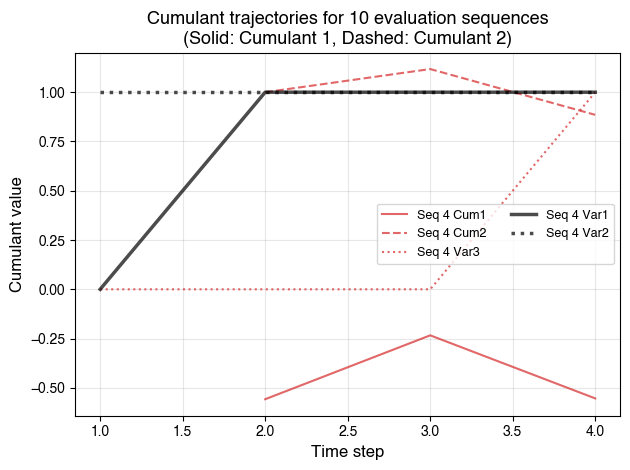

number of timesteps 3
timesteps [2 3 4]
timesteps2 [1 2 3 4]
pred_var 4


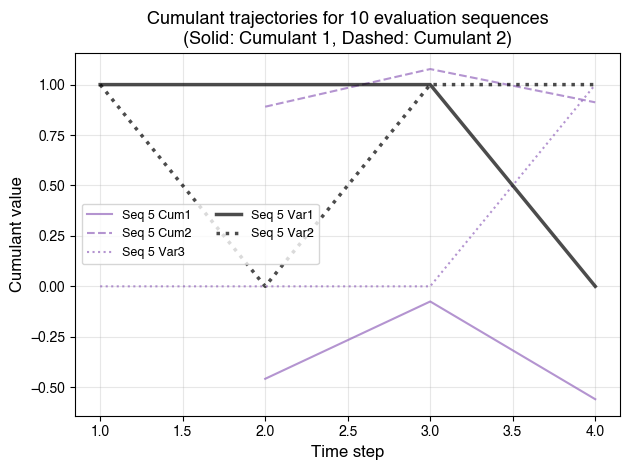

number of timesteps 7
timesteps [2 3 4 5 6 7 8]
timesteps2 [1 2 3 4 5 6 7 8]
pred_var 8


/var/folders/d5/md8j7hzd7hd4x541d_l6bmzm0000gp/T/ipykernel_32267/924798660.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9, ncol=2)


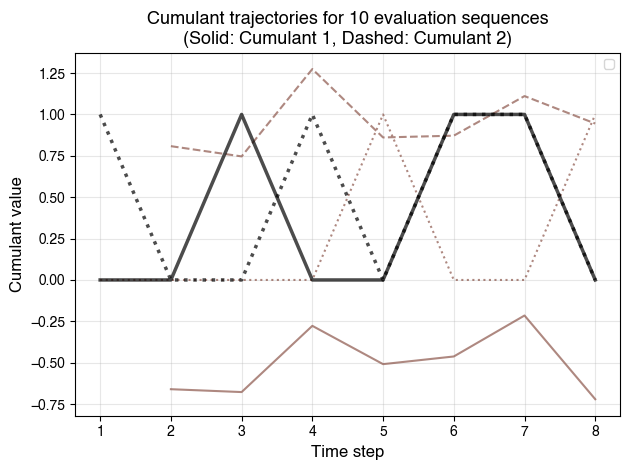

number of timesteps 9
timesteps [ 2  3  4  5  6  7  8  9 10]
timesteps2 [ 1  2  3  4  5  6  7  8  9 10]
pred_var 10


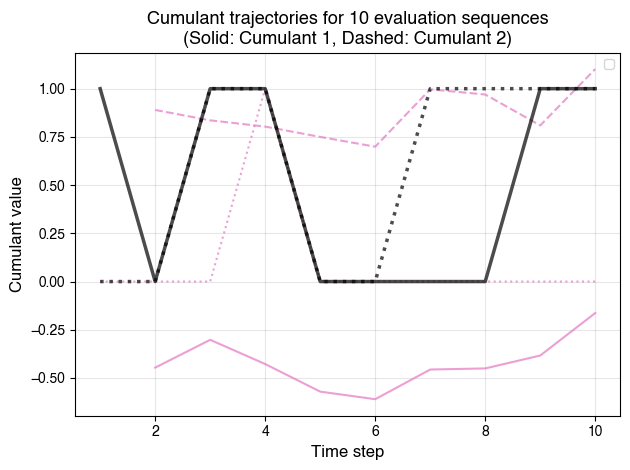

number of timesteps 2
timesteps [2 3]
timesteps2 [1 2 3]
pred_var 3


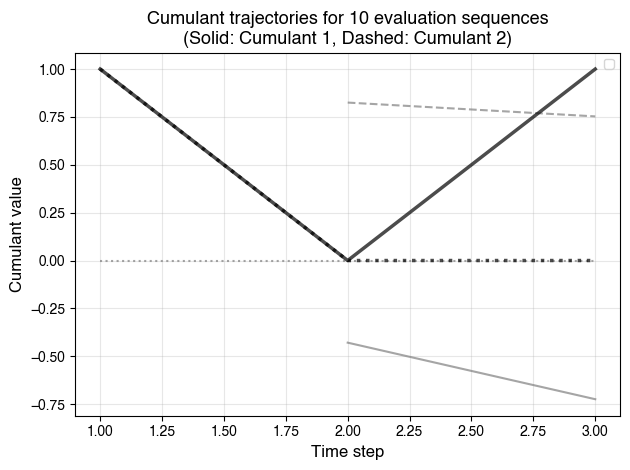

number of timesteps 5
timesteps [2 3 4 5 6]
timesteps2 [1 2 3 4 5 6]
pred_var 6


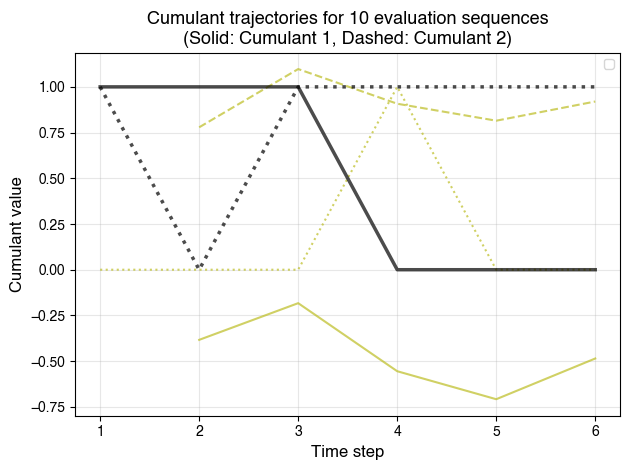

number of timesteps 4
timesteps [2 3 4 5]
timesteps2 [1 2 3 4 5]
pred_var 5


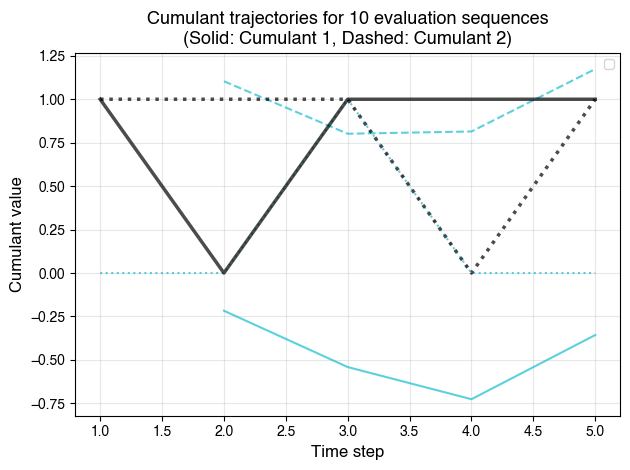

In [18]:

# Plot trajectories for all sequences
plt.figure(figsize=(10, 6))

# Get a colormap for different sequences
colors = plt.cm.tab10(range(num_sequences))

for seq_idx, cumulants_np in enumerate(all_cumulants):
    # seq_idx =1
    T, ncum_effective = cumulants_np.shape
    timesteps = np.array(range(2, T+2))
    color = colors[seq_idx]
    
    print("number of timesteps", T)
    print("timesteps", timesteps)
    
    # Plot cumulant 1 as solid line
    if ncum_effective >= 1:
        plt.plot(timesteps, cumulants_np[:, 0], linestyle='-', linewidth=1.5, 
                color=color, alpha=0.7, label=f'Seq {seq_idx+1} Cum1' if seq_idx < 5 else '')
    
    # Plot cumulant 2 as dashed line in same color
    if ncum_effective >= 2:
        plt.plot(timesteps, cumulants_np[:, 1], linestyle='--', linewidth=1.5, 
                color=color, alpha=0.7, label=f'Seq {seq_idx+1} Cum2' if seq_idx < 5 else '')
    timesteps2 = np.array(range(1, T+2))
    print("timesteps2", timesteps2)
    print("pred_var", len(pred_var[seq_idx]))
    plt.plot(timesteps2, pred_var[seq_idx], linestyle=':', linewidth=1.5, 
                    color=color, alpha=0.7, label=f'Seq {seq_idx+1} Var3' if seq_idx < 5 else '')
    plt.plot(timesteps2, first_var[seq_idx], linestyle='-', linewidth=2.5, 
                    color='black', alpha=0.7, label=f'Seq {seq_idx+1} Var1' if seq_idx < 5 else '')
    plt.plot(timesteps2, second_var[seq_idx], linestyle=':', linewidth=2.5, 
                    color='black', alpha=0.7, label=f'Seq {seq_idx+1} Var2' if seq_idx < 5 else '')
    

    plt.xlabel("Time step", fontsize=12)
    plt.ylabel("Cumulant value", fontsize=12)
    plt.title(f"Cumulant trajectories for {num_sequences} evaluation sequences\n(Solid: Cumulant 1, Dashed: Cumulant 2)", fontsize=13)
    plt.legend(fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
